# Results in the Schrodinger picture

Notebook to compute $\langle \delta p_i^2 \rangle = \langle (p_i - p_{i,0})^2 \rangle$ using the Schrodinger picture. We expand the fields at first order in $z$ so 
$$A_+(x^+, y, z) = \frac{1}{2} \left[ -\frac{z}{t} A_\eta(t, x=t, y) + A_x(t, x=t, y)\right]$$
and for the transverse fields $A_y(x^+, y, z) = A_y(t, x=t, y)$ and $A_z(x^+, y, z) =  A_\eta(t, x=t, y)/t$.

## 1. Results for $L=1\, \mathrm{fm}$

We fix a small lattice size $L=1\, \mathrm{fm}$ wich allows us to go to very fine lattices but at the cost of our results being sensitive to the lattice IR cutoff $\sim 1/L$. If we discover that we don't need such a fine lattices then one may expect the results to be also good for $L=5\, \mathrm{fm}$ where we are no longer sensitive to the lattice IR. We get results for $N= 128, 256, 512$

### Canonic momentum broeadening

We start computing this component

In [1]:
# We create a list with the files to read

Nevs = 50

p2_file_list_128 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=128_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_64_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/pperp/evolution_Pperp_sq.dat' %(nev) for nev in range(Nevs)]
pp0_file_list_128 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=128_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_64_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_P0.dat' %(nev) for nev in range(Nevs)]

p2_file_list_256 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=256_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_128_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_64/pperp/evolution_Pperp_sq.dat' %(nev) for nev in range(Nevs)]
pp0_file_list_256 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=256_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_128_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_64/PIperp/evolution_2Re_P_P0.dat' %(nev) for nev in range(Nevs)]

p2_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_256_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_128/pperp/evolution_Pperp_sq.dat' %(nev) for nev in range(Nevs)]
pp0_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_256_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_128/PIperp/evolution_2Re_P_P0.dat' %(nev) for nev in range(Nevs)]

In [2]:
# We convert to an array of DataFrames

import pandas as pd 
import numpy as np

p2_df_list_128 = []; pp0_df_list_128 = []
p2_df_list_256 = []; pp0_df_list_256 = []
p2_df_list_512 = []; pp0_df_list_512 = []

for i in range(Nevs):
    p2_df_128 = [pd.read_table(p2_file_list_128[i], header = None)]
    pp0_df_128 = [pd.read_table(pp0_file_list_128[i], header = None)]
    
    p2_df_256 = [pd.read_table(p2_file_list_256[i], header = None)]
    pp0_df_256 = [pd.read_table(pp0_file_list_256[i], header = None)]
    
    p2_df_512 = [pd.read_table(p2_file_list_512[i], header = None)]
    pp0_df_512 = [pd.read_table(pp0_file_list_512[i], header = None)]
    
    p2_df_list_128.append(p2_df_128); pp0_df_list_128.append(pp0_df_128)
    p2_df_list_256.append(p2_df_256); pp0_df_list_256.append(pp0_df_256)
    p2_df_list_512.append(p2_df_512); pp0_df_list_512.append(pp0_df_512)

p2_data_128 = np.array(p2_df_list_128); pp0_data_128 = np.array(pp0_df_list_128)
p2_data_256 = np.array(p2_df_list_256); pp0_data_256 = np.array(pp0_df_list_256)
p2_data_512 = np.array(p2_df_list_512); pp0_data_512 = np.array(pp0_df_list_512)

In [3]:
# We average over color and events
p2_av_128 = np.average(p2_data_128, axis=(0, 1)); pp0_av_128 = np.average(pp0_data_128, axis=(0, 1))
p2_av_256 = np.average(p2_data_256, axis=(0, 1)); pp0_av_256 = np.average(pp0_data_256, axis=(0, 1))
p2_av_512 = np.average(p2_data_512, axis=(0, 1)); pp0_av_512 = np.average(pp0_data_512, axis=(0, 1))

In [4]:
# Take the different components of canonic momentum
xplus_128 = p2_av_128[:, 0]; xplus_256 = p2_av_256[:, 0]; xplus_512 = p2_av_512[:, 0]

p2_z_128 = p2_av_128[:, 1]; p2_z_256 = p2_av_256[:, 1]; p2_z_512 = p2_av_512[:, 1]
p2_y_128 = p2_av_128[:, 2]; p2_y_256 = p2_av_256[:, 2]; p2_y_512 = p2_av_512[:, 2]

pp0_z_128 = pp0_av_128[:, 1]; pp0_z_256 = pp0_av_256[:, 1]; pp0_z_512 = pp0_av_512[:, 1]
pp0_y_128 = pp0_av_128[:, 2]; pp0_y_256 = pp0_av_256[:, 2]; pp0_y_512 = pp0_av_512[:, 2]

In [5]:
# We compute momentum broadening
delta_p2_y_128 = p2_y_128 + p2_y_128[0] - pp0_y_128
delta_p2_z_128 = p2_z_128 + p2_z_128[0] - pp0_z_128

delta_p2_y_256 = p2_y_256 + p2_y_256[0] - pp0_y_256 
delta_p2_z_256 = p2_z_256 + p2_z_256[0] - pp0_z_256

delta_p2_y_512 = p2_y_512 + p2_y_512[0] - pp0_y_512
delta_p2_z_512 = p2_z_512 + p2_z_512[0] - pp0_z_512

### Field contribution

In [6]:
# We create a list with the files to read

Nevs = 50

A2_file_list_128 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=128_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_64_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
AA0_file_list_128 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=128_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_64_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_gA0.dat' %(nev) for nev in range(Nevs)]

A2_file_list_256 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=256_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_128_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_64/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
AA0_file_list_256 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=256_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_128_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_64/PIperp/evolution_2Re_gA_gA0.dat' %(nev) for nev in range(Nevs)]

A2_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_256_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_128/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
AA0_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_256_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_128/PIperp/evolution_2Re_gA_gA0.dat' %(nev) for nev in range(Nevs)]

In [7]:
# We convert to an array of DataFrames

import pandas as pd 
import numpy as np

A2_df_list_128 = []; AA0_df_list_128 = []
A2_df_list_256 = []; AA0_df_list_256 = []
A2_df_list_512 = []; AA0_df_list_512 = []

for i in range(Nevs):
    A2_df_128 = [pd.read_table(A2_file_list_128[i], header = None)]
    AA0_df_128 = [pd.read_table(AA0_file_list_128[i], header = None)]
    
    A2_df_256 = [pd.read_table(A2_file_list_256[i], header = None)]
    AA0_df_256 = [pd.read_table(AA0_file_list_256[i], header = None)]
    
    A2_df_512 = [pd.read_table(A2_file_list_512[i], header = None)]
    AA0_df_512 = [pd.read_table(AA0_file_list_512[i], header = None)]

    A2_df_list_128.append(A2_df_128); AA0_df_list_128.append(AA0_df_128)
    A2_df_list_256.append(A2_df_256); AA0_df_list_256.append(AA0_df_256)
    A2_df_list_512.append(A2_df_512); AA0_df_list_512.append(AA0_df_512)

A2_data_128 = np.array(A2_df_list_128);AA0_data_128 = np.array(AA0_df_list_128)
A2_data_256 = np.array(A2_df_list_256);AA0_data_256 = np.array(AA0_df_list_256)
A2_data_512 = np.array(A2_df_list_512);AA0_data_512 = np.array(AA0_df_list_512)

In [8]:
# We average over color and events
A2_av_128 = np.average(A2_data_128, axis=(0, 1)); AA0_av_128 = np.average(AA0_data_128, axis=(0, 1))
A2_av_256 = np.average(A2_data_256, axis=(0, 1)); AA0_av_256 = np.average(AA0_data_256, axis=(0, 1))
A2_av_512 = np.average(A2_data_512, axis=(0, 1)); AA0_av_512 = np.average(AA0_data_512, axis=(0, 1))

In [9]:
# Take the different components of canonic momentum
xplus_128 = A2_av_128[:, 0]; xplus_256 = A2_av_256[:, 0]; xplus_512 = A2_av_512[:, 0]

A2_z_128 = A2_av_128[:, 2]; A2_z_256 = A2_av_256[:, 2]; A2_z_512 = A2_av_512[:, 2]
A2_y_128 = A2_av_128[:, 6]; A2_y_256 = A2_av_256[:, 6]; A2_y_512 = A2_av_512[:, 6]

AA0_z_128 = AA0_av_128[:, 1]; AA0_z_256 = AA0_av_256[:, 1]; AA0_z_512 = AA0_av_512[:, 1]
AA0_y_128 = AA0_av_128[:, 2]; AA0_y_256 = AA0_av_256[:, 2]; AA0_y_512 = AA0_av_512[:, 2]

In [10]:
# We compute momentum broadening
delta_A2_y_128 = A2_y_128 + A2_y_128[0] -  AA0_y_128
delta_A2_z_128 = A2_z_128 + A2_z_128[0] - AA0_z_128

delta_A2_y_256 = A2_y_256 + A2_y_256[0] -  AA0_y_256
delta_A2_z_256 = A2_z_256 + A2_z_256[0] - AA0_z_256

delta_A2_y_512 = A2_y_512 + A2_y_512[0] -  AA0_y_512
delta_A2_z_512 = A2_z_512 + A2_z_512[0] - AA0_z_512

### Cross terms

In [11]:
# We create a list with the files to read

Nevs = 50

pA_file_list_128 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=128_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_64_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
pA0_file_list_128 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=128_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_64_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_gA0.dat' %(nev) for nev in range(Nevs)]
p0A_file_list_128 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=128_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_64_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_P0.dat' %(nev) for nev in range(Nevs)]

pA_file_list_256 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=256_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_128_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_64/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
pA0_file_list_256 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=256_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_128_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_64/PIperp/evolution_2Re_P_gA0.dat' %(nev) for nev in range(Nevs)]      
p0A_file_list_256 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=256_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_128_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_64/PIperp/evolution_2Re_gA_P0.dat' %(nev) for nev in range(Nevs)]

pA_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_256_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_128/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
pA0_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_256_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_128/PIperp/evolution_2Re_P_gA0.dat' %(nev) for nev in range(Nevs)]      
p0A_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=1_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_2_Nperp_256_Leta_2.500000_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_128/PIperp/evolution_2Re_gA_P0.dat' %(nev) for nev in range(Nevs)]

In [12]:
# We convert to an array of DataFrames

import pandas as pd 
import numpy as np

pA_df_list_128 = []; pA0_df_list_128 = []; p0A_df_list_128 = []
pA_df_list_256 = []; pA0_df_list_256 = []; p0A_df_list_256 = []
pA_df_list_512 = []; pA0_df_list_512 = []; p0A_df_list_512 = []

for i in range(Nevs):
    pA_df_128 = [pd.read_table(pA_file_list_128[i], header = None)]
    pA0_df_128 = [pd.read_table(pA0_file_list_128[i], header = None)]
    p0A_df_128 = [pd.read_table(p0A_file_list_128[i], header = None)]
    
    pA_df_256 = [pd.read_table(pA_file_list_256[i], header = None)]
    pA0_df_256 = [pd.read_table(pA0_file_list_256[i], header = None)]
    p0A_df_256 = [pd.read_table(p0A_file_list_256[i], header = None)]
    
    pA_df_512 = [pd.read_table(pA_file_list_512[i], header = None)]
    pA0_df_512 = [pd.read_table(pA0_file_list_512[i], header = None)]
    p0A_df_512 = [pd.read_table(p0A_file_list_512[i], header = None)]

    pA_df_list_128.append(pA_df_128); pA0_df_list_128.append(pA0_df_128); p0A_df_list_128.append(p0A_df_128)
    pA_df_list_256.append(pA_df_256); pA0_df_list_256.append(pA0_df_256); p0A_df_list_256.append(p0A_df_256)
    pA_df_list_512.append(pA_df_512); pA0_df_list_512.append(pA0_df_512); p0A_df_list_512.append(p0A_df_512)

pA_data_128 = np.array(pA_df_list_128); pA0_data_128 = np.array(pA0_df_list_128); p0A_data_128 = np.array(p0A_df_list_128)
pA_data_256 = np.array(pA_df_list_256); pA0_data_256 = np.array(pA0_df_list_256); p0A_data_256 = np.array(p0A_df_list_256)
pA_data_512 = np.array(pA_df_list_512); pA0_data_512 = np.array(pA0_df_list_512); p0A_data_512 = np.array(p0A_df_list_512)

In [13]:
# We average over color and events
pA_av_128 = np.average(pA_data_128, axis=(0, 1)); pA0_av_128 = np.average(pA0_data_128, axis=(0, 1)); p0A_av_128 = np.average(p0A_data_128, axis=(0, 1))
pA_av_256 = np.average(pA_data_256, axis=(0, 1)); pA0_av_256 = np.average(pA0_data_256, axis=(0, 1)); p0A_av_256 = np.average(p0A_data_256, axis=(0, 1))
pA_av_512 = np.average(pA_data_512, axis=(0, 1)); pA0_av_512 = np.average(pA0_data_512, axis=(0, 1)); p0A_av_512 = np.average(p0A_data_512, axis=(0, 1))

In [14]:
# Take the different components of canonic momentum
xplus_128 = pA_av_128[:, 0]; xplus_256 = pA_av_256[:, 0]; xplus_512 = pA_av_512[:, 0]

pA_z_128 = pA_av_128[:, 3]; pA_z_256 = pA_av_256[:, 3]; pA_z_512 = pA_av_512[:, 3]
pA_y_128 = pA_av_128[:, 7]; pA_y_256 = pA_av_256[:, 7]; pA_y_512 = pA_av_512[:, 7]

pA0_z_128 = pA0_av_128[:, 1]; pA0_z_256 = pA0_av_256[:, 1]; pA0_z_512 = pA0_av_512[:, 1]
pA0_y_128 = pA0_av_128[:, 2]; pA0_y_256 = pA0_av_256[:, 2]; pA0_y_512 = pA0_av_512[:, 2]

p0A_z_128 = p0A_av_128[:, 1]; p0A_z_256 = p0A_av_256[:, 1]; p0A_z_512 = p0A_av_512[:, 1]
p0A_y_128 = p0A_av_128[:, 2]; p0A_y_256 = p0A_av_256[:, 2]; p0A_y_512 = p0A_av_512[:, 2]

In [15]:
# We compute momentum broadening
delta_pA_y_128 = pA_y_128 + pA_y_128[0] -  pA0_y_128 - p0A_y_128
delta_pA_z_128 = pA_z_128 + pA_z_128[0] -  pA0_z_128 - p0A_z_128

delta_pA_y_256 = pA_y_256 + pA_y_256[0] -  pA0_y_256 - p0A_y_256
delta_pA_z_256 = pA_z_256 + pA_z_256[0] -  pA0_z_256 - p0A_z_256

delta_pA_y_512 = pA_y_512 + pA_y_512[0] -  pA0_y_512 - p0A_y_512
delta_pA_z_512 = pA_z_512 + pA_z_512[0] -  pA0_z_512 - p0A_z_512

### Kinetic momentum

In [16]:
# We compute the quantum result

delta_pkin_y2_128 = delta_p2_y_128 + delta_A2_y_128 + delta_pA_y_128
delta_pkin_z2_128 = delta_p2_z_128 + delta_A2_z_128 + delta_pA_z_128

delta_pkin_y2_256 = delta_p2_y_256 + delta_A2_y_256 + delta_pA_y_256
delta_pkin_z2_256 = delta_p2_z_256 + delta_A2_z_256 + delta_pA_z_256

delta_pkin_y2_512 = delta_p2_y_512 + delta_A2_y_512 + delta_pA_y_512
delta_pkin_z2_512 = delta_p2_z_512 + delta_A2_z_512 + delta_pA_z_512

In [17]:
# We load the classical result

xp_class = np.loadtxt('classical_results_L=1/classical_pi.txt')[0]
delta_pkin_y2_class = np.loadtxt('classical_results_L=1/classical_pi.txt')[1]
delta_pkin_z2_class = np.loadtxt('classical_results_L=1/classical_pi.txt')[2]

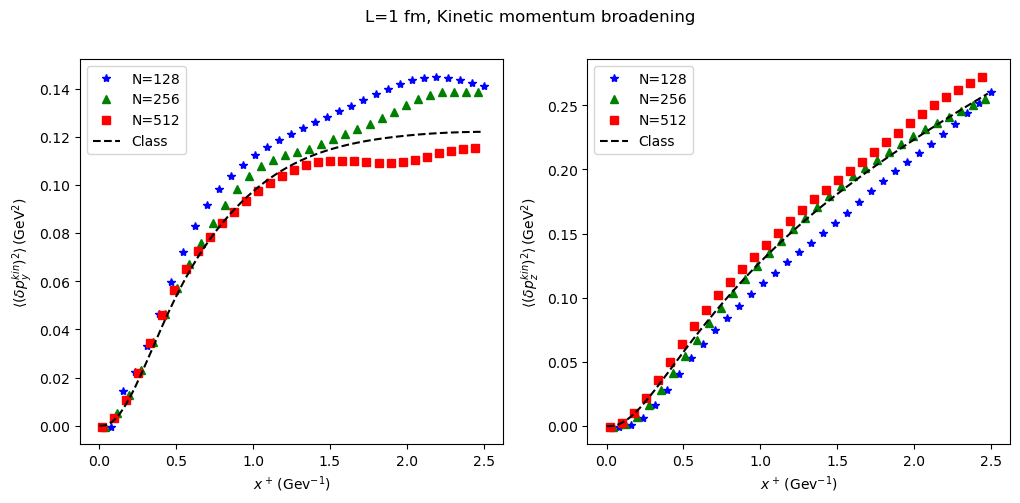

In [18]:
# We plot the results

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(xplus_128+1/(128*0.2)*2, delta_pkin_y2_128, '*', label='N=128', color='blue')
axes[0].plot(xplus_256+1/(256*0.2)*2, delta_pkin_y2_256, '^', label='N=256', color='green')
axes[0].plot(xplus_512+1/(512*0.2)*2, delta_pkin_y2_512, 's', label='N=512', color='red')
axes[0].plot(xp_class*2/0.2, delta_pkin_y2_class/3, label='Class', color='black', linestyle='--')
axes[0].set_xlabel(r'$x^+\, (\mathrm{Gev}^{-1})$')
axes[0].set_ylabel(r'$\langle (\delta p^{kin}_y)^2 \rangle\,  (\mathrm{GeV}^{2})$')
axes[0].legend()

axes[1].plot(xplus_128+1/(128*0.2)*2, delta_pkin_z2_128, '*', label='N=128', color='blue')
axes[1].plot(xplus_256+1/(256*0.2)*2, delta_pkin_z2_256, '^', label='N=256', color='green')
axes[1].plot(xplus_512+1/(512*0.2)*2, delta_pkin_z2_512, 's', label='N=512', color='red')
axes[1].plot(xp_class*2/0.2, delta_pkin_z2_class/3, label='Class', color='black', linestyle='--')
axes[1].set_xlabel(r'$x^+\, (\mathrm{Gev}^{-1})$')
axes[1].set_ylabel(r'$\langle (\delta p^{kin}_z)^2 \rangle\,  (\mathrm{GeV}^{2})$')
axes[1].legend()

fig.suptitle('L=1 fm, Kinetic momentum broadening')
plt.show()

fig.savefig('L=1_plots/Kinetic_momentum_broadening.png', bbox_inches='tight')

## 2. Repeat with $L=5\, \mathrm{fm}$

Let us now see if we can still get decent results in the limit where $m_g$ acts as the IR regulator and not $1/L$

### Canonic momentum broadening

In [19]:
# We create a list with the files to read

Nevs = 50

p2_file_list_256 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=256_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_128_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_16/pperp/evolution_Pperp_sq.dat' %(nev) for nev in range(Nevs)]
pp0_file_list_256 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=256_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_128_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_16/PIperp/evolution_2Re_P_P0.dat' %(nev) for nev in range(Nevs)]

p2_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/pperp/evolution_Pperp_sq.dat' %(nev) for nev in range(Nevs)]
pp0_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_P0.dat' %(nev) for nev in range(Nevs)]

p2_file_list_1024 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=1024_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_512_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_64/pperp/evolution_Pperp_sq.dat' %(nev) for nev in range(Nevs)]
pp0_file_list_1024 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=1024_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_512_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_64/PIperp/evolution_2Re_P_P0.dat' %(nev) for nev in range(Nevs)]

In [20]:
# We convert to an array of DataFrames

import pandas as pd 
import numpy as np

p2_df_list_256 = []; pp0_df_list_256 = []
p2_df_list_512 = []; pp0_df_list_512 = []
p2_df_list_1024 = []; pp0_df_list_1024 = []

for i in range(Nevs):
    p2_df_256 = [pd.read_table(p2_file_list_256[i], header = None)]
    pp0_df_256 = [pd.read_table(pp0_file_list_256[i], header = None)]
    
    p2_df_512 = [pd.read_table(p2_file_list_512[i], header = None)]
    pp0_df_512 = [pd.read_table(pp0_file_list_512[i], header = None)]
    
    p2_df_1024 = [pd.read_table(p2_file_list_1024[i], header = None)]
    pp0_df_1024 = [pd.read_table(pp0_file_list_1024[i], header = None)]
    
    p2_df_list_256.append(p2_df_256); pp0_df_list_256.append(pp0_df_256)
    p2_df_list_512.append(p2_df_512); pp0_df_list_512.append(pp0_df_512)
    p2_df_list_1024.append(p2_df_1024); pp0_df_list_1024.append(pp0_df_1024)

p2_data_256 = np.array(p2_df_list_256); pp0_data_256 = np.array(pp0_df_list_256)
p2_data_512 = np.array(p2_df_list_512); pp0_data_512 = np.array(pp0_df_list_512)
p2_data_1024 = np.array(p2_df_list_1024); pp0_data_1024 = np.array(pp0_df_list_1024)

In [21]:
# We average over color and events
p2_av_256 = np.average(p2_data_256, axis=(0, 1)); pp0_av_256 = np.average(pp0_data_256, axis=(0, 1))
p2_av_512 = np.average(p2_data_512, axis=(0, 1)); pp0_av_512 = np.average(pp0_data_512, axis=(0, 1))
p2_av_1024 = np.average(p2_data_1024, axis=(0, 1)); pp0_av_1024 = np.average(pp0_data_1024, axis=(0, 1))

In [22]:
# Take the different components of canonic momentum
xplus_256 = p2_av_256[:, 0]; xplus_512 = p2_av_512[:, 0]; xplus_1024 = p2_av_1024[:, 0]

p2_z_256 = p2_av_256[:, 1]; p2_z_512 = p2_av_512[:, 1]
p2_y_256 = p2_av_256[:, 2]; p2_y_512 = p2_av_512[:, 2]

pp0_z_256 = pp0_av_256[:, 1]; pp0_z_512 = pp0_av_512[:, 1]
pp0_y_256 = pp0_av_256[:, 2]; pp0_y_512 = pp0_av_512[:, 2]

p2_z_1024 = p2_av_1024[:, 1]; p2_y_1024 = p2_av_1024[:, 2]
pp0_z_1024 = pp0_av_1024[:, 1]; pp0_y_1024 = pp0_av_1024[:, 2]

In [23]:
# We compute momentum broadening

delta_p2_y_256 = p2_y_256 + p2_y_256[0] - pp0_y_256 
delta_p2_z_256 = p2_z_256 + p2_z_256[0] - pp0_z_256

delta_p2_y_512 = p2_y_512 + p2_y_512[0] - pp0_y_512
delta_p2_z_512 = p2_z_512 + p2_z_512[0] - pp0_z_512

delta_p2_y_1024 = p2_y_1024 + p2_y_1024[0] - pp0_y_1024
delta_p2_z_1024 = p2_z_1024 + p2_z_1024[0] - pp0_z_1024

### Field contribution

In [24]:
# We create a list with the files to read

Nevs = 50

A2_file_list_256 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=256_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_128_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_16/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
AA0_file_list_256 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=256_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_128_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_16/PIperp/evolution_2Re_gA_gA0.dat' %(nev) for nev in range(Nevs)]

A2_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
AA0_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_gA0.dat' %(nev) for nev in range(Nevs)]

A2_file_list_1024 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=1024_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_512_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_64/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
AA0_file_list_1024 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=1024_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_512_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_64/PIperp/evolution_2Re_gA_gA0.dat' %(nev) for nev in range(Nevs)]

In [25]:
# We convert to an array of DataFrames

import pandas as pd 
import numpy as np

A2_df_list_256 = []; AA0_df_list_256 = []
A2_df_list_512 = []; AA0_df_list_512 = []
A2_df_list_1024 = []; AA0_df_list_1024 = []

for i in range(Nevs):
    
    A2_df_256 = [pd.read_table(A2_file_list_256[i], header = None)]
    AA0_df_256 = [pd.read_table(AA0_file_list_256[i], header = None)]
    
    A2_df_512 = [pd.read_table(A2_file_list_512[i], header = None)]
    AA0_df_512 = [pd.read_table(AA0_file_list_512[i], header = None)]
    
    A2_df_1024 = [pd.read_table(A2_file_list_1024[i], header = None)]
    AA0_df_1024 = [pd.read_table(AA0_file_list_1024[i], header = None)]

    A2_df_list_256.append(A2_df_256); AA0_df_list_256.append(AA0_df_256)
    A2_df_list_512.append(A2_df_512); AA0_df_list_512.append(AA0_df_512)
    A2_df_list_1024.append(A2_df_1024); AA0_df_list_1024.append(AA0_df_1024)

A2_data_256 = np.array(A2_df_list_256); AA0_data_256 = np.array(AA0_df_list_256)
A2_data_512 = np.array(A2_df_list_512); AA0_data_512 = np.array(AA0_df_list_512)
A2_data_1024 = np.array(A2_df_list_1024); AA0_data_1024 = np.array(AA0_df_list_1024)

In [26]:
# We average over color and events
A2_av_256 = np.average(A2_data_256, axis=(0, 1)); AA0_av_256 = np.average(AA0_data_256, axis=(0, 1))
A2_av_512 = np.average(A2_data_512, axis=(0, 1)); AA0_av_512 = np.average(AA0_data_512, axis=(0, 1))
A2_av_1024 = np.average(A2_data_1024, axis=(0, 1)); AA0_av_1024 = np.average(AA0_data_1024, axis=(0, 1))

In [27]:
# Take the different components of canonic momentum
xplus_256 = A2_av_256[:, 0]; xplus_512 = A2_av_512[:, 0]; xplus_1024 = A2_av_1024[:, 0]

A2_z_256 = A2_av_256[:, 2]; A2_z_512 = A2_av_512[:, 2]; A2_z_1024 = A2_av_1024[:, 2]
A2_y_256 = A2_av_256[:, 6]; A2_y_512 = A2_av_512[:, 6]; A2_y_1024 = A2_av_1024[:, 6]

AA0_z_256 = AA0_av_256[:, 1]; AA0_z_512 = AA0_av_512[:, 1]; AA0_z_1024 = AA0_av_1024[:, 1]
AA0_y_256 = AA0_av_256[:, 2]; AA0_y_512 = AA0_av_512[:, 2]; AA0_y_1024 = AA0_av_1024[:, 2]

In [28]:
# We compute momentum broadening

delta_A2_y_256 = A2_y_256 + A2_y_256[0] -  AA0_y_256
delta_A2_z_256 = A2_z_256 + A2_z_256[0] - AA0_z_256

delta_A2_y_512 = A2_y_512 + A2_y_512[0] -  AA0_y_512
delta_A2_z_512 = A2_z_512 + A2_z_512[0] - AA0_z_512

delta_A2_y_1024 = A2_y_1024 + A2_y_1024[0] -  AA0_y_1024
delta_A2_z_1024 = A2_z_1024 + A2_z_1024[0] - AA0_z_1024

### Cross term

In [29]:
# We create a list with the files to read

Nevs = 50

pA_file_list_256 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=256_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_128_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_16/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
pA0_file_list_256 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=256_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_128_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_16/PIperp/evolution_2Re_P_gA0.dat' %(nev) for nev in range(Nevs)]      
p0A_file_list_256 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=256_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_128_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_16/PIperp/evolution_2Re_gA_P0.dat' %(nev) for nev in range(Nevs)]

pA_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
pA0_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_gA0.dat' %(nev) for nev in range(Nevs)]      
p0A_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_P0.dat' %(nev) for nev in range(Nevs)]

pA_file_list_1024 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=1024_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_512_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_64/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
pA0_file_list_1024 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=1024_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_512_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_64/PIperp/evolution_2Re_P_gA0.dat' %(nev) for nev in range(Nevs)]      
p0A_file_list_1024 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=1024_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_512_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_64/PIperp/evolution_2Re_gA_P0.dat' %(nev) for nev in range(Nevs)]

In [30]:
# We convert to an array of DataFrames

import pandas as pd 
import numpy as np

pA_df_list_256 = []; pA0_df_list_256 = []; p0A_df_list_256 = []
pA_df_list_512 = []; pA0_df_list_512 = []; p0A_df_list_512 = []
pA_df_list_1024 = []; pA0_df_list_1024 = []; p0A_df_list_1024 = []

for i in range(Nevs):
    
    pA_df_256 = [pd.read_table(pA_file_list_256[i], header = None)]
    pA0_df_256 = [pd.read_table(pA0_file_list_256[i], header = None)]
    p0A_df_256 = [pd.read_table(p0A_file_list_256[i], header = None)]
    
    pA_df_512 = [pd.read_table(pA_file_list_512[i], header = None)]
    pA0_df_512 = [pd.read_table(pA0_file_list_512[i], header = None)]
    p0A_df_512 = [pd.read_table(p0A_file_list_512[i], header = None)]
    
    pA_df_1024 = [pd.read_table(pA_file_list_1024[i], header = None)]
    pA0_df_1024 = [pd.read_table(pA0_file_list_1024[i], header = None)]
    p0A_df_1024 = [pd.read_table(p0A_file_list_1024[i], header = None)]

    pA_df_list_256.append(pA_df_256); pA0_df_list_256.append(pA0_df_256); p0A_df_list_256.append(p0A_df_256)
    pA_df_list_512.append(pA_df_512); pA0_df_list_512.append(pA0_df_512); p0A_df_list_512.append(p0A_df_512)
    pA_df_list_1024.append(pA_df_1024); pA0_df_list_1024.append(pA0_df_1024); p0A_df_list_1024.append(p0A_df_1024)

pA_data_256 = np.array(pA_df_list_256); pA0_data_256 = np.array(pA0_df_list_256); p0A_data_256 = np.array(p0A_df_list_256)
pA_data_512 = np.array(pA_df_list_512); pA0_data_512 = np.array(pA0_df_list_512); p0A_data_512 = np.array(p0A_df_list_512)
pA_data_1024 = np.array(pA_df_list_1024); pA0_data_1024 = np.array(pA0_df_list_1024); p0A_data_1024 = np.array(p0A_df_list_1024)

In [31]:
# We average over color and events
pA_av_256 = np.average(pA_data_256, axis=(0, 1)); pA0_av_256 = np.average(pA0_data_256, axis=(0, 1)); p0A_av_256 = np.average(p0A_data_256, axis=(0, 1))
pA_av_512 = np.average(pA_data_512, axis=(0, 1)); pA0_av_512 = np.average(pA0_data_512, axis=(0, 1)); p0A_av_512 = np.average(p0A_data_512, axis=(0, 1))
pA_av_1024 = np.average(pA_data_1024, axis=(0, 1)); pA0_av_1024 = np.average(pA0_data_1024, axis=(0, 1)); p0A_av_1024 = np.average(p0A_data_1024, axis=(0, 1))

In [32]:
# Take the different components of canonic momentum
xplus_256 = pA_av_256[:, 0]; xplus_512 = pA_av_512[:, 0]; xplus_1024 = pA_av_1024[:, 0]

pA_z_256 = pA_av_256[:, 3]; pA_z_512 = pA_av_512[:, 3]; pA_z_1024 = pA_av_1024[:, 3]
pA_y_256 = pA_av_256[:, 7]; pA_y_512 = pA_av_512[:, 7]; pA_y_1024 = pA_av_1024[:, 7]

pA0_z_256 = pA0_av_256[:, 1]; pA0_z_512 = pA0_av_512[:, 1]; pA0_z_1024 = pA0_av_1024[:, 1]
pA0_y_256 = pA0_av_256[:, 2]; pA0_y_512 = pA0_av_512[:, 2]; pA0_y_1024 = pA0_av_1024[:, 2]

p0A_z_256 = p0A_av_256[:, 1]; p0A_z_512 = p0A_av_512[:, 1]; p0A_z_1024 = p0A_av_1024[:, 1]
p0A_y_256 = p0A_av_256[:, 2]; p0A_y_512 = p0A_av_512[:, 2]; p0A_y_1024 = p0A_av_1024[:, 2]

In [33]:
# We compute momentum broadening

delta_pA_y_256 = pA_y_256 + pA_y_256[0] -  pA0_y_256 - p0A_y_256
delta_pA_z_256 = pA_z_256 + pA_z_256[0] -  pA0_z_256 - p0A_z_256

delta_pA_y_512 = pA_y_512 + pA_y_512[0] -  pA0_y_512 - p0A_y_512
delta_pA_z_512 = pA_z_512 + pA_z_512[0] -  pA0_z_512 - p0A_z_512

delta_pA_y_1024 = pA_y_1024 + pA_y_1024[0] -  pA0_y_1024 - p0A_y_1024
delta_pA_z_1024 = pA_z_1024 + pA_z_1024[0] -  pA0_z_1024 - p0A_z_1024

### Kinetic momentum

In [34]:
# We compute the quantum result

delta_pkin_y2_256 = delta_p2_y_256 + delta_A2_y_256 + delta_pA_y_256
delta_pkin_z2_256 = delta_p2_z_256 + delta_A2_z_256 + delta_pA_z_256

delta_pkin_y2_512 = delta_p2_y_512 + delta_A2_y_512 + delta_pA_y_512
delta_pkin_z2_512 = delta_p2_z_512 + delta_A2_z_512 + delta_pA_z_512

delta_pkin_y2_1024 = delta_p2_y_1024 + delta_A2_y_1024 + delta_pA_y_1024
delta_pkin_z2_1024 = delta_p2_z_1024 + delta_A2_z_1024 + delta_pA_z_1024

In [35]:
# We load the classical result

xp_class = np.loadtxt('classical_results_L=5/classical_pi.txt')[0]
delta_pkin_y2_class = np.loadtxt('classical_results_L=5/classical_pi.txt')[1]
delta_pkin_z2_class = np.loadtxt('classical_results_L=5/classical_pi.txt')[2]

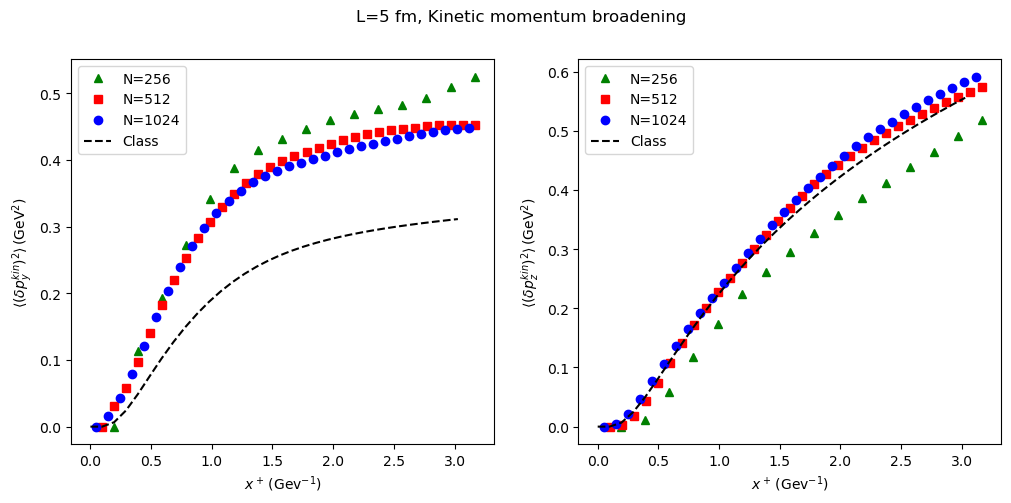

In [36]:
# We plot the results

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(xplus_256+5/(256*0.2)*2, delta_pkin_y2_256, '^', label='N=256', color='green')
axes[0].plot(xplus_512+5/(512*0.2)*2, delta_pkin_y2_512, 's', label='N=512', color='red')
axes[0].plot(xplus_1024+5/(1024*0.2)*2, delta_pkin_y2_1024, 'o', label='N=1024', color='blue')
axes[0].plot(xp_class*2/0.2, delta_pkin_y2_class/3, label='Class', color='black', linestyle='--')
axes[0].set_xlabel(r'$x^+\, (\mathrm{Gev}^{-1})$')
axes[0].set_ylabel(r'$\langle (\delta p^{kin}_y)^2 \rangle\,  (\mathrm{GeV}^{2})$')
axes[0].legend()

axes[1].plot(xplus_256+5/(256*0.2)*2, delta_pkin_z2_256, '^', label='N=256', color='green')
axes[1].plot(xplus_512+5/(512*0.2)*2, delta_pkin_z2_512, 's', label='N=512', color='red')
axes[1].plot(xplus_1024+5/(1024*0.2)*2, delta_pkin_z2_1024, 'o', label='N=1024', color='blue')
axes[1].plot(xp_class*2/0.2, delta_pkin_z2_class/3, label='Class', color='black', linestyle='--')
axes[1].set_xlabel(r'$x^+\, (\mathrm{Gev}^{-1})$')
axes[1].set_ylabel(r'$\langle (\delta p^{kin}_z)^2 \rangle\,  (\mathrm{GeV}^{2})$')
axes[1].legend()

fig.suptitle('L=5 fm, Kinetic momentum broadening')
plt.show()

# fig.savefig('L=5_plots/Kinetic_momentum_broadening.png', bbox_inches='tight')

## 3. Compare to mid-rapidity

We want to check if the discrepancies in the $y$ direction come from the change of coordinates

In [1]:
# We create a list with the files to read

Nevs = 50

p2_file_list = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/pperp/evolution_Pperp_sq.dat' %(nev) for nev in range(Nevs)]
pp0_file_list = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_P0.dat' %(nev) for nev in range(Nevs)]

p2_file_list_mr = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_mid_rapidity/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/pperp/evolution_Pperp_sq.dat' %(nev) for nev in range(Nevs)]
pp0_file_list_mr = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_mid_rapidity/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_P0.dat' %(nev) for nev in range(Nevs)]

In [2]:
# We convert to an array of DataFrames

import pandas as pd 
import numpy as np

p2_df_list = []; pp0_df_list = []
p2_df_list_mr = []; pp0_df_list_mr = []

for i in range(Nevs):
    
    p2_df = [pd.read_table(p2_file_list[i], header = None)]
    pp0_df = [pd.read_table(pp0_file_list[i], header = None)]
    
    p2_df_mr = [pd.read_table(p2_file_list_mr[i], header = None)]
    pp0_df_mr = [pd.read_table(pp0_file_list_mr[i], header = None)]
    
    p2_df_list.append(p2_df); pp0_df_list.append(pp0_df)
    p2_df_list_mr.append(p2_df_mr); pp0_df_list_mr.append(pp0_df_mr)
    
p2_data = np.array(p2_df_list); pp0_data = np.array(pp0_df_list)
p2_data_mr = np.array(p2_df_list_mr); pp0_data_mr = np.array(pp0_df_list_mr)

In [3]:
# We average over color and events
p2_av = np.average(p2_data, axis=(0, 1)); pp0_av = np.average(pp0_data, axis=(0, 1))
p2_av_mr = np.average(p2_data_mr, axis=(0, 1)); pp0_av_mr = np.average(pp0_data_mr, axis=(0, 1))

In [4]:
# Take the different components of canonic momentum
xplus = p2_av[:, 0]

p2_z = p2_av[:, 1]; p2_y = p2_av[:, 2]
p2_z_mr = p2_av_mr[:, 1]; p2_y_mr = p2_av_mr[:, 2]

pp0_z = pp0_av[:, 1]; pp0_y = pp0_av[:, 2]
pp0_z_mr = pp0_av_mr[:, 1]; pp0_y_mr = pp0_av_mr[:, 2]


In [5]:
# We compute momentum broadening

delta_p2_y = p2_y + p2_y[0] - pp0_y
delta_p2_z = p2_z + p2_z[0] - pp0_z

delta_p2_y_mr = p2_y_mr + p2_y_mr[0] - pp0_y_mr
delta_p2_z_mr = p2_z_mr + p2_z_mr[0] - pp0_z_mr

In [6]:
print(delta_p2_y_mr)
print(delta_p2_z_mr)

[0.        0.0205974 0.0810152 0.175827  0.2962092 0.4318792 0.5731322
 0.7124384 0.8452918 0.9700606 1.0869784 1.1968786 1.3002788 1.397112
 1.486887  1.5689724 1.642886  1.7087152 1.767431  1.8207284 1.8703866
 1.91757   1.9625644 2.0050984 2.0449946 2.0826324 2.118956  2.155022
 2.1913592 2.2275946 2.2626732 2.295626        nan]
[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. nan]


### Field contribution

In [7]:
# We create a list with the files to read

Nevs = 50

A2_file_list = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
AA0_file_list = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_gA0.dat' %(nev) for nev in range(Nevs)]

A2_file_list_mr = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_mid_rapidity/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
AA0_file_list_mr = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_mid_rapidity/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_gA0.dat' %(nev) for nev in range(Nevs)]

In [8]:
# We convert to an array of DataFrames

import pandas as pd 
import numpy as np

A2_df_list = []; AA0_df_list = []
A2_df_list_mr = []; AA0_df_list_mr = []

for i in range(Nevs):
    
    A2_df = [pd.read_table(A2_file_list[i], header = None)]
    AA0_df = [pd.read_table(AA0_file_list[i], header = None)]
    
    A2_df_mr = [pd.read_table(A2_file_list_mr[i], header = None)]
    AA0_df_mr = [pd.read_table(AA0_file_list_mr[i], header = None)]
    
    A2_df_list.append(A2_df); AA0_df_list.append(AA0_df)
    A2_df_list_mr.append(A2_df_mr); AA0_df_list_mr.append(AA0_df_mr)

A2_data = np.array(A2_df_list); AA0_data = np.array(AA0_df_list)
A2_data_mr = np.array(A2_df_list_mr); AA0_data_mr = np.array(AA0_df_list_mr)

In [9]:
# We average over color and events
A2_av = np.average(A2_data, axis=(0, 1)); AA0_av = np.average(AA0_data, axis=(0, 1))
A2_av_mr = np.average(A2_data_mr, axis=(0, 1)); AA0_av_mr = np.average(AA0_data_mr, axis=(0, 1))

In [10]:
# Take the different components of canonic momentum
xplus = A2_av[:, 0]

A2_z = A2_av[:, 2]; A2_z_mr = A2_av_mr[:, 2]
A2_y = A2_av[:, 6]; A2_y_mr = A2_av_mr[:, 6]

AA0_z = AA0_av[:, 1]; AA0_z_mr = AA0_av_mr[:, 1]
AA0_y = AA0_av[:, 2]; AA0_y_mr = AA0_av_mr[:, 2]

In [11]:
# We compute momentum broadening

delta_A2_y = A2_y + A2_y[0] -  AA0_y
delta_A2_z = A2_z + A2_z[0] - AA0_z

delta_A2_y_mr = A2_y_mr + A2_y_mr[0] -  AA0_y_mr
delta_A2_z_mr = A2_z_mr + A2_z_mr[0] - AA0_z_mr

In [12]:
print(delta_A2_y)
print(delta_A2_y_mr)

[2.00000000e-07 1.34524400e-02 5.60392400e-02 1.43097080e-01
 2.66217180e-01 4.14426660e-01 5.76426040e-01 7.42147880e-01
 9.04166700e-01 1.05759022e+00 1.19842189e+00 1.32332795e+00
 1.43129806e+00 1.52475958e+00 1.60798524e+00 1.68429962e+00
 1.75516375e+00 1.82112904e+00 1.88274601e+00 1.94048952e+00
 1.99441470e+00 2.04414863e+00 2.08895275e+00 2.12773836e+00
 2.15880768e+00 2.18015654e+00 2.19091062e+00 2.19255429e+00
 2.18880161e+00 2.18432092e+00 2.18342781e+00 2.18909459e+00
 1.32441288e+00]
[-4.44089210e-16  1.94367000e-02  7.93094800e-02  1.90190140e-01
  3.37387340e-01  5.05739420e-01  6.82515880e-01  8.57794640e-01
  1.02462520e+00  1.17875972e+00  1.31805556e+00  1.44257132e+00
  1.55387125e+00  1.65348004e+00  1.74242104e+00  1.82143129e+00
  1.89077787e+00  1.95015939e+00  1.99962383e+00  2.04090622e+00
  2.07734031e+00  2.11195674e+00  2.14597541e+00  2.17912366e+00
  2.21084492e+00  2.24081958e+00  2.26881966e+00  2.29497304e+00
  2.32005657e+00  2.34520761e+00  2.3718

### Cross term

In [13]:
# We create a list with the files to read

Nevs = 50

pA_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
pA0_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_gA0.dat' %(nev) for nev in range(Nevs)]      
p0A_file_list_512 = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_t0/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_P0.dat' %(nev) for nev in range(Nevs)]

pA_file_list_mr = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_mid_rapidity/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_Piperp_sq_exp_autonomy.dat' %(nev) for nev in range(Nevs)]
pA0_file_list_mr = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_mid_rapidity/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_P_gA0.dat' %(nev) for nev in range(Nevs)]      
p0A_file_list_mr = ['/lustre/HQCD/carlos.lamas/qJetLFH_KineticSchrodinger/output/simulations_v2/L=5_N=512_mid_rapidity/result_%i_OUTPUT_VGlasma_nophase_R_q_g_1.000_WF_Init_q_Gaussian_inP_nx0_ny0_wx_10.000000_wy_10.000000_cQ_11_hQ_0_mq0_4.200_mq_4.200_mg_0.150_Lperp_13_Nperp_256_Leta_3.167350_Neta_1_Lmin_10.00_Kmax_2_g2mu_0.000_onMPIrank_0_step_32/PIperp/evolution_2Re_gA_P0.dat' %(nev) for nev in range(Nevs)]

In [14]:
# We convert to an array of DataFrames

import pandas as pd 
import numpy as np

pA_df_list = []; pA0_df_list = []; p0A_df_list = []
pA_df_list_mr = []; pA0_df_list_mr = []; p0A_df_list_mr = []

for i in range(Nevs):
    
    pA_df = [pd.read_table(pA_file_list_512[i], header = None)]
    pA0_df = [pd.read_table(pA0_file_list_512[i], header = None)]
    p0A_df = [pd.read_table(p0A_file_list_512[i], header = None)]
    
    pA_df_mr = [pd.read_table(pA_file_list_mr[i], header = None)]
    pA0_df_mr = [pd.read_table(pA0_file_list_mr[i], header = None)]
    p0A_df_mr = [pd.read_table(p0A_file_list_mr[i], header = None)]
    
    pA_df_list.append(pA_df); pA0_df_list.append(pA0_df); p0A_df_list.append(p0A_df)
    pA_df_list_mr.append(pA_df_mr); pA0_df_list_mr.append(pA0_df_mr); p0A_df_list_mr.append(p0A_df_mr)

pA_data = np.array(pA_df_list); pA0_data = np.array(pA0_df_list); p0A_data = np.array(p0A_df_list)
pA_data_mr = np.array(pA_df_list_mr); pA0_data_mr = np.array(pA0_df_list_mr); p0A_data_mr = np.array(p0A_df_list_mr)

In [15]:
# We average over color and events
pA_av = np.average(pA_data, axis=(0, 1)); pA0_av = np.average(pA0_data, axis=(0, 1)); p0A_av = np.average(p0A_data, axis=(0, 1))
pA_av_mr = np.average(pA_data_mr, axis=(0, 1)); pA0_av_mr = np.average(pA0_data_mr, axis=(0, 1)); p0A_av_mr = np.average(p0A_data_mr, axis=(0, 1))

In [16]:
# Take the different components of canonic momentum
xplus = pA_av[:, 0]

pA_z = pA_av[:, 3]; pA_y = pA_av[:, 7]
pA_z_mr = pA_av_mr[:, 3]; pA_y_mr = pA_av_mr[:, 7]

pA0_z = pA0_av[:, 1]; pA0_y = pA0_av[:, 2]
pA0_z_mr = pA0_av_mr[:, 1]; pA0_y_mr = pA0_av_mr[:, 2]

p0A_z = p0A_av[:, 1]; p0A_y = p0A_av[:, 2]
p0A_z_mr = p0A_av_mr[:, 1]; p0A_y_mr = p0A_av_mr[:, 2]

In [17]:
# We compute momentum broadening

delta_pA_y = pA_y + pA_y[0] -  pA0_y - p0A_y
delta_pA_z = pA_z + pA_z[0] -  pA0_z - p0A_z

delta_pA_y_mr = pA_y_mr + pA_y_mr[0] -  pA0_y_mr - p0A_y_mr
delta_pA_z_mr = pA_z_mr + pA_z_mr[0] -  pA0_z_mr - p0A_z_mr

### Compute kinetic momentum

In [18]:
# We compute the quantum result

delta_pkin_y2 = delta_p2_y + delta_A2_y + delta_pA_y
delta_pkin_z2 = delta_p2_z + delta_A2_z + delta_pA_z

delta_pkin_y2_mr = delta_p2_y_mr + delta_A2_y_mr + delta_pA_y_mr
delta_pkin_z2_mr = delta_p2_z_mr + delta_A2_z_mr + delta_pA_z_mr

In [19]:
# We load the classical result

xp_class = np.loadtxt('classical_results_L=5/classical_pi.txt')[0]
delta_pkin_y2_class = np.loadtxt('classical_results_L=5/classical_pi.txt')[1]
delta_pkin_z2_class = np.loadtxt('classical_results_L=5/classical_pi.txt')[2]

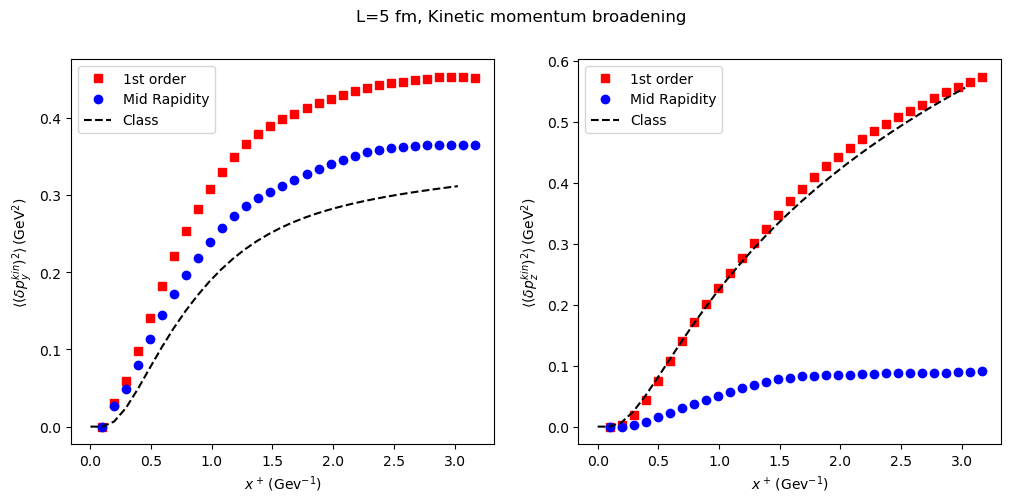

In [20]:
# We plot the results

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(xplus+5/(512*0.2)*2, delta_pkin_y2, 's', label='1st order', color='red')
axes[0].plot(xplus+5/(512*0.2)*2, delta_pkin_y2_mr, 'o', label='Mid Rapidity', color='blue')
axes[0].plot(xp_class*2/0.2, delta_pkin_y2_class/3, label='Class', color='black', linestyle='--')
axes[0].set_xlabel(r'$x^+\, (\mathrm{Gev}^{-1})$')
axes[0].set_ylabel(r'$\langle (\delta p^{kin}_y)^2 \rangle\,  (\mathrm{GeV}^{2})$')
axes[0].legend()

axes[1].plot(xplus+5/(512*0.2)*2, delta_pkin_z2, 's', label='1st order', color='red')
axes[1].plot(xplus+5/(512*0.2)*2, delta_pkin_z2_mr, 'o', label='Mid Rapidity', color='blue')
axes[1].plot(xp_class*2/0.2, delta_pkin_z2_class/3, label='Class', color='black', linestyle='--')
axes[1].set_xlabel(r'$x^+\, (\mathrm{Gev}^{-1})$')
axes[1].set_ylabel(r'$\langle (\delta p^{kin}_z)^2 \rangle\,  (\mathrm{GeV}^{2})$')
axes[1].legend()

fig.suptitle('L=5 fm, Kinetic momentum broadening')
plt.show()

fig.savefig('L=5_plots/Kinetic_momentum_mid_rapidity.png', bbox_inches='tight')